# **#  XGBoost CLASSIFIER — ISLANDING DETECTION**
- Direct comparison with MLP baseline
- Same features: 108 DWT stats (Sym4 Level 2, StandardScaled)
- Same splits: 60/20/20 stratified at recording level


In [1]:
# --- Cell 1: Imports ---
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.metrics import confusion_matrix, accuracy_score
RANDOM_STATE = 55

from google.colab import drive
drive.mount('/content/drive')

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]
DATA_PATH   = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Dataset/scaled_dataset/'
FIG_PATH    = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/Figures/'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# --- Cell 2: Load arrays ---
X_train = np.load(DATA_PATH + 'X_train_scaled.npy')
X_val   = np.load(DATA_PATH + 'X_val_scaled.npy')
X_test  = np.load(DATA_PATH + 'X_test_scaled.npy')
y_train = np.load(DATA_PATH + 'y_train_bal.npy')
y_val   = np.load(DATA_PATH + 'y_val.npy')
y_test  = np.load(DATA_PATH + 'y_test.npy')

print("Shapes loaded:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Shapes loaded:
  X_train: (45728, 108), y_train: (45728,)
  X_val:   (27495, 108),   y_val:   (27495,)
  X_test:  (27495, 108),  y_test:  (27495,)


In [5]:
df = pd.DataFrame(X_train)

In [6]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,98,99,100,101,102,103,104,105,106,107
0,-0.266363,0.008631,-0.023455,0.315003,1.136384,0.959718,0.615356,0.679682,1.754640,-0.019960,...,7.175154,7.066842,3.869585,2.746375,1.728941,0.975719,4.699809,1.162413,-0.238016,-4.005654
1,0.580272,0.286677,0.297645,0.281318,-0.317440,-0.450857,-0.552824,-0.244407,-0.633613,-0.722979,...,0.299370,0.183058,-0.703581,-1.172397,-1.162664,-0.897807,-1.220663,-0.176084,1.740590,2.259019
2,0.592484,0.281778,0.294113,0.258537,-0.380900,-0.506888,-0.593892,-0.300238,-0.650264,-0.740738,...,-0.031831,-0.094521,-0.981394,-1.529757,-1.520677,-1.040596,-1.280898,0.444896,-0.543819,1.855866
3,0.573533,0.272828,0.284062,0.275949,-0.281490,-0.431716,-0.557688,-0.232643,-0.530456,-0.753756,...,0.115864,0.061167,-0.230586,-1.485232,-1.646874,-1.070200,-1.439471,0.885894,-0.551464,0.295838
4,0.593417,0.274388,0.287261,0.238160,-0.423020,-0.533801,-0.598250,-0.328195,-0.633158,-0.753741,...,-0.109882,-0.107517,0.119438,-1.159803,-1.353186,-0.945810,-0.719428,0.933813,-0.530961,-1.433271


In [ ]:
BAND_NAMES = ['cA2', 'cD2', 'cD1']
STAT_NAMES = ['mean', 'std', 'rms', 'peak',
              'crest_factor', 'impulse_factor', 'shape_factor',
              'clearance_factor', 'kurtosis', 'skewness',
              'thd', 'sinad']

FEATURE_NAMES = []
for phase in ['Va', 'Vb', 'Vc']:
    for band in BAND_NAMES:
        for stat in STAT_NAMES:
            FEATURE_NAMES.append(phase + '_' + band + '_' + stat)

assert len(FEATURE_NAMES) == 108, f"Expected 108, got {len(FEATURE_NAMES)}"
assert len(FEATURE_NAMES) == len(set(FEATURE_NAMES)), "Duplicate names found!"

print(f"Feature names verified: {len(FEATURE_NAMES)} unique features")

# Wrap training set in DataFrame for inspection
import pandas as pd
X_train_df = pd.DataFrame(X_train, columns=FEATURE_NAMES)
X_train_df.head()

Feature names verified: 108 unique features


,Va_cA2_mean,Va_cA2_std,Va_cA2_rms,Va_cA2_peak,Va_cA2_crest_factor,Va_cA2_impulse_factor,Va_cA2_shape_factor,Va_cA2_clearance_factor,Va_cA2_kurtosis,Va_cA2_skewness,...,Vc_cD1_rms,Vc_cD1_peak,Vc_cD1_crest_factor,Vc_cD1_impulse_factor,Vc_cD1_shape_factor,Vc_cD1_clearance_factor,Vc_cD1_kurtosis,Vc_cD1_skewness,Vc_cD1_thd,Vc_cD1_sinad
0,-0.266363,0.008631,-0.023455,0.315003,1.136384,0.959718,0.615356,0.679682,1.754640,-0.019960,...,7.175154,7.066842,3.869585,2.746375,1.728941,0.975719,4.699809,1.162413,-0.238016,-4.005654
1,0.580272,0.286677,0.297645,0.281318,-0.317440,-0.450857,-0.552824,-0.244407,-0.633613,-0.722979,...,0.299370,0.183058,-0.703581,-1.172397,-1.162664,-0.897807,-1.220663,-0.176084,1.740590,2.259019
2,0.592484,0.281778,0.294113,0.258537,-0.380900,-0.506888,-0.593892,-0.300238,-0.650264,-0.740738,...,-0.031831,-0.094521,-0.981394,-1.529757,-1.520677,-1.040596,-1.280898,0.444896,-0.543819,1.855866
3,0.573533,0.272828,0.284062,0.275949,-0.281490,-0.431716,-0.557688,-0.232643,-0.530456,-0.753756,...,0.115864,0.061167,-0.230586,-1.485232,-1.646874,-1.070200,-1.439471,0.885894,-0.551464,0.295838
4,0.593417,0.274388,0.287261,0.238160,-0.423020,-0.533801,-0.598250,-0.328195,-0.633158,-0.753741,...,-0.109882,-0.107517,0.119438,-1.159803,-1.353186,-0.945810,-0.719428,0.933813,-0.530961,-1.433271


In [ ]:
# ================================================================
#  SAVE FEATURE NAMES TO GOOGLE DRIVE
# ================================================================
import json

phases = ['Va', 'Vb', 'Vc']
bands  = ['cA2', 'cD2', 'cD1']
stats  = [
    'mean', 'std', 'rms', 'peak',
    'crest_factor', 'impulse_factor', 'shape_factor',
    'clearance_factor', 'kurtosis', 'skewness', 'thd', 'sinad'
]

feature_names_list = [
    f"{phase}_{band}_{stat}"
    for phase in phases
    for band  in bands
    for stat  in stats
]

# Save to Drive
save_path = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/feature_names.json'

with open(save_path, 'w') as f:
    json.dump(feature_names_list, f, indent=2)

print(f"Saved {len(feature_names_list)} feature names to:")
print(f"  {save_path}")
print(f"\nVerification — first 5:  {feature_names_list[:5]}")
print(f"Verification — last 5:   {feature_names_list[-5:]}")
print(f"\nKey indices:")
for feat in ['Va_cA2_peak', 'Vb_cD2_crest_factor', 'Vc_cD1_clearance_factor']:
    print(f"  {feat:<30} → index {feature_names_list.index(feat)}")

Saved 108 feature names to:
  /content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/feature_names.json

Verification — first 5:  ['Va_cA2_mean', 'Va_cA2_std', 'Va_cA2_rms', 'Va_cA2_peak', 'Va_cA2_crest_factor']
Verification — last 5:   ['Vc_cD1_clearance_factor', 'Vc_cD1_kurtosis', 'Vc_cD1_skewness', 'Vc_cD1_thd', 'Vc_cD1_sinad']

Key indices:
  Va_cA2_peak                    → index 3
  Vb_cD2_crest_factor            → index 52
  Vc_cD1_clearance_factor        → index 103


Fitting PCA...
Fitting t-SNE...
Fitting UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


All fits complete.


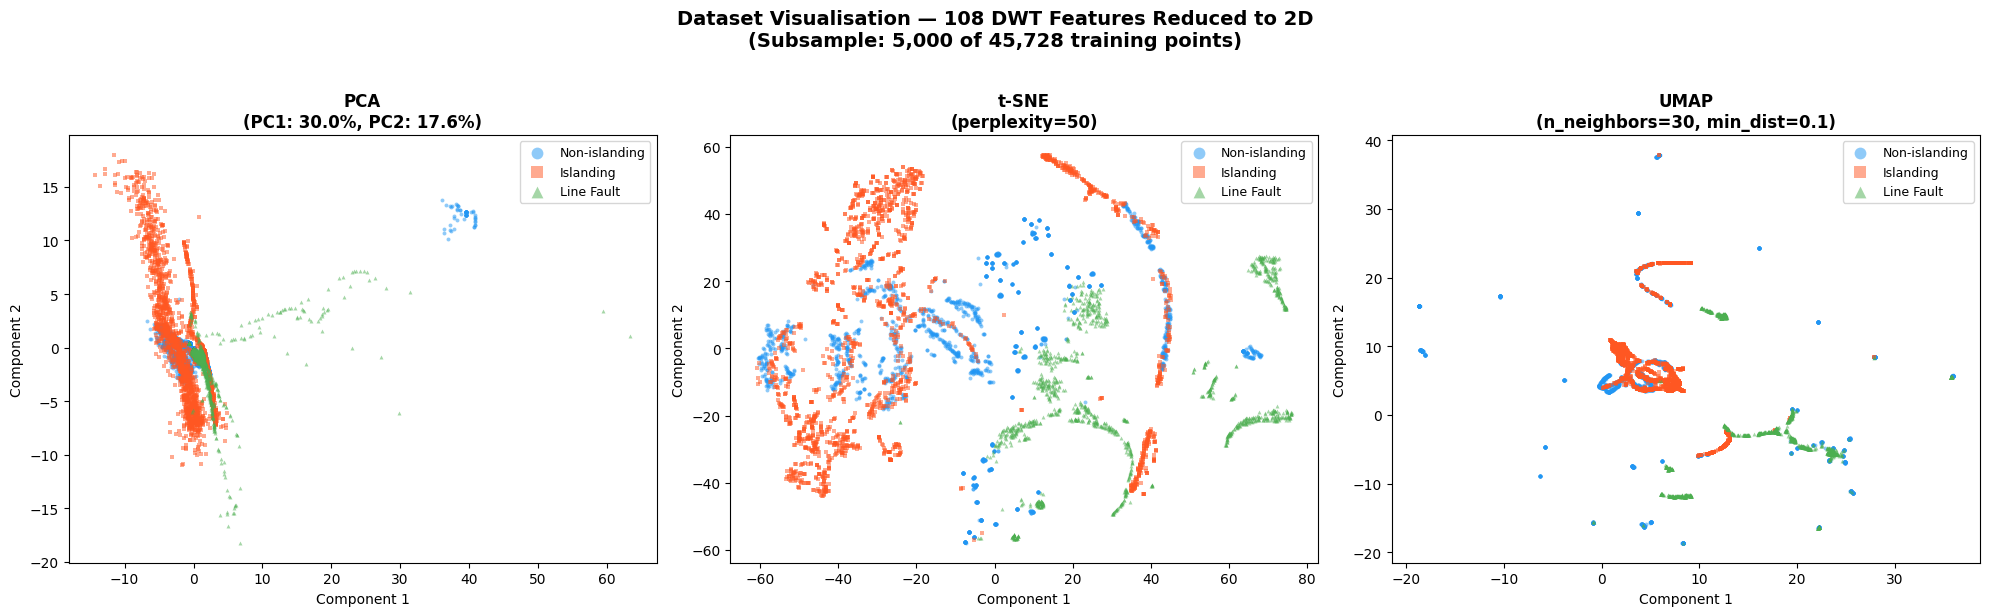

In [ ]:
# ================================================================
#  DATASET VISUALISATION — PCA, t-SNE, UMAP
#  Reduces 108 features to 2D for class separation analysis
# ================================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# UMAP needs installing in Colab
# !pip install umap-learn -q
import umap

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]
COLORS      = ["#2196F3", "#FF5722", "#4CAF50"]
MARKERS     = ["o", "s", "^"]

# ----------------------------------------------------------------
# Use a subsample for speed (t-SNE and UMAP are slow on 45k rows)
# ----------------------------------------------------------------
np.random.seed(42)
N_SAMPLE = 5000   # 5k points plots cleanly and is representative

idx = np.random.choice(len(X_train), N_SAMPLE, replace=False)
X_vis = X_train[idx]
y_vis = y_train[idx]

# ----------------------------------------------------------------
# Fit all three
# ----------------------------------------------------------------
print("Fitting PCA...")
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_vis)
var_explained = pca.explained_variance_ratio_ * 100

print("Fitting t-SNE...")
tsne   = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_vis)

print("Fitting UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap  = reducer.fit_transform(X_vis)

print("All fits complete.")

# ----------------------------------------------------------------
# Plot
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets = [
    (X_pca,  f"PCA\n(PC1: {var_explained[0]:.1f}%, PC2: {var_explained[1]:.1f}%)"),
    (X_tsne, "t-SNE\n(perplexity=50)"),
    (X_umap, "UMAP\n(n_neighbors=30, min_dist=0.1)"),
]

for ax, (X_2d, title) in zip(axes, datasets):
    for i, (name, color, marker) in enumerate(zip(CLASS_NAMES, COLORS, MARKERS)):
        mask = y_vis == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=name, marker=marker,
                   s=8, alpha=0.5, linewidths=0)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Component 1", fontsize=10)
    ax.set_ylabel("Component 2", fontsize=10)
    ax.legend(markerscale=3, fontsize=9, loc='best')

fig.suptitle("Dataset Visualisation — 108 DWT Features Reduced to 2D\n"
             f"(Subsample: {N_SAMPLE:,} of {len(X_train):,} training points)",
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIG_PATH + 'dataset_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

XGBoost Classifier

In [3]:
xgb_model = XGBClassifier(
    objective             = 'multi:softprob',
    num_class             = 3,
    eval_metric           = 'mlogloss',
    n_estimators          = 500,
    early_stopping_rounds = 10,
    max_depth             = 4,      # default 6 → reduce tree complexity
    min_child_weight      = 5,      # default 1 → require more samples per node
    subsample             = 0.8,    # use 80% of rows per tree
    colsample_bytree      = 0.8,    # use 80% of features per tree
    reg_lambda            = 2.0,    # L2 regularisation, default 1
    random_state          = 42,
    n_jobs                = -1
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = 10
)

print(f"Best round:    {xgb_model.best_iteration}")
print(f"Best val loss: {xgb_model.best_score:.4f}")

[0]	validation_0-mlogloss:0.76788
[10]	validation_0-mlogloss:0.18375
[20]	validation_0-mlogloss:0.12080
[30]	validation_0-mlogloss:0.09843
[40]	validation_0-mlogloss:0.08533
[50]	validation_0-mlogloss:0.07868
[60]	validation_0-mlogloss:0.07582
[70]	validation_0-mlogloss:0.07179
[80]	validation_0-mlogloss:0.06899
[90]	validation_0-mlogloss:0.06741
[100]	validation_0-mlogloss:0.06626
[110]	validation_0-mlogloss:0.06495
[120]	validation_0-mlogloss:0.06376
[130]	validation_0-mlogloss:0.06274
[140]	validation_0-mlogloss:0.06249
[150]	validation_0-mlogloss:0.06152
[160]	validation_0-mlogloss:0.06121
[170]	validation_0-mlogloss:0.06095
[180]	validation_0-mlogloss:0.06041
[190]	validation_0-mlogloss:0.05972
[200]	validation_0-mlogloss:0.05929
[210]	validation_0-mlogloss:0.05891
[220]	validation_0-mlogloss:0.05857
[230]	validation_0-mlogloss:0.05861
Best round:    220
Best val loss: 0.0586


In [ ]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\nMetrics validation:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9988
Metrics validation:
	Accuracy score: 0.9777


In [4]:
# ================================================================
#  XGBOOST - CLASSIFICATION REPORT (TRAINING & VALIDATION)
# ================================================================
from sklearn.metrics import classification_report, accuracy_score

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

# --- Predictions ---
y_train_pred = xgb_model.predict(X_train)
y_val_pred   = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)
# --- Reports ---
for name, y_true, y_pred in [
    ("Training",   y_train, y_train_pred),
    ("Validation", y_val,   y_val_pred),
    ("Test", y_test,   y_test_pred)

]:
    acc = accuracy_score(y_true, y_pred) * 100
    print(f"\n{'='*55}")
    print(f"  {name}  |  Accuracy: {acc:.2f}%")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES,
                                digits=4))


  Training  |  Accuracy: 99.88%
               precision    recall  f1-score   support

Non-islanding     0.9978    0.9989    0.9984     17136
    Islanding     0.9989    0.9978    0.9984     17136
   Line Fault     1.0000    1.0000    1.0000     11456

     accuracy                         0.9988     45728
    macro avg     0.9989    0.9989    0.9989     45728
 weighted avg     0.9988    0.9988    0.9988     45728


  Validation  |  Accuracy: 97.77%
               precision    recall  f1-score   support

Non-islanding     0.9874    0.9785    0.9829     17959
    Islanding     0.9344    0.9603    0.9472      5712
   Line Fault     0.9990    1.0000    0.9995      3824

     accuracy                         0.9777     27495
    macro avg     0.9736    0.9796    0.9765     27495
 weighted avg     0.9780    0.9777    0.9778     27495


  Test  |  Accuracy: 97.53%
               precision    recall  f1-score   support

Non-islanding     0.9874    0.9748    0.9810     17959
    Islanding   

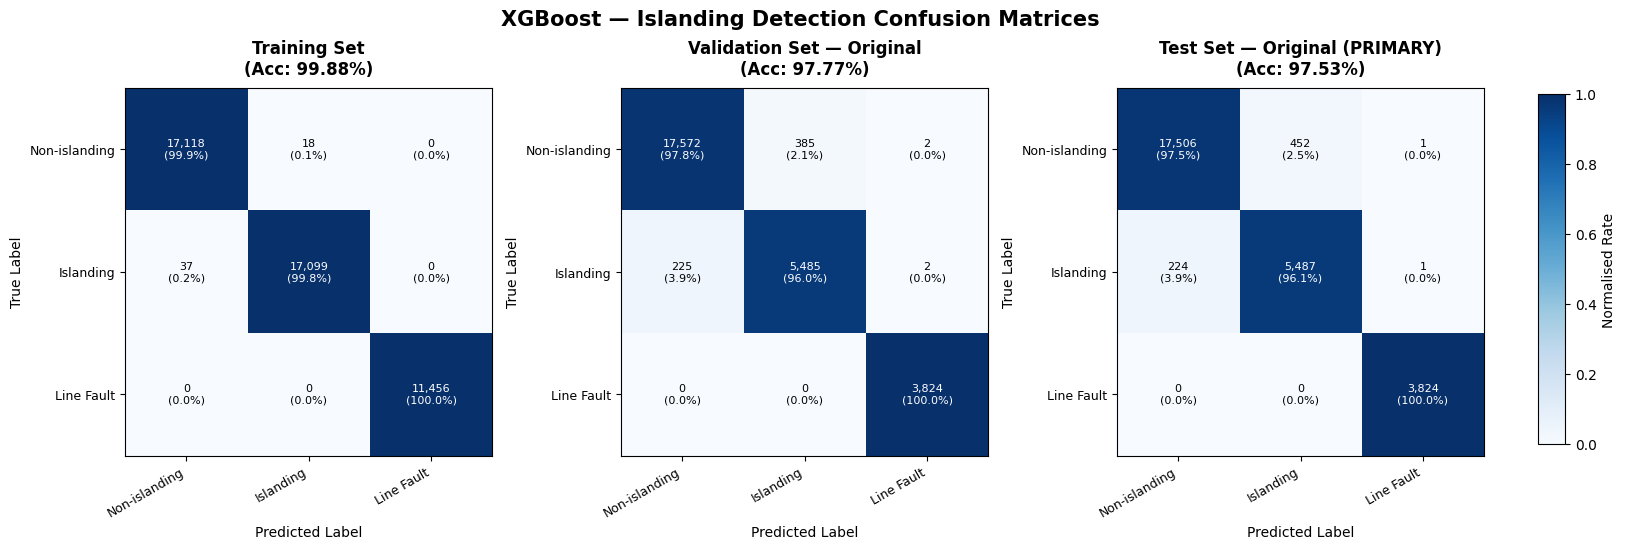

Saved to figures/xgb_confusion_matrices.png


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

def plot_confusion_matrix(ax, cm, title, class_names):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=1)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks); ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(ticks); ax.set_yticklabels(class_names, fontsize=9)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)",
                ha="center", va="center", fontsize=8, color=color)

# --- Confusion matrices ---
cm_train = confusion_matrix(y_train, y_train_pred)
cm_val   = confusion_matrix(y_val,   y_val_pred)
cm_test  = confusion_matrix(y_test,  y_test_pred)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (cm_train, f"Training Set\n(Acc: {accuracy_score(y_train, y_train_pred)*100:.2f}%)"),
    (cm_val,   f"Validation Set — Original\n(Acc: {accuracy_score(y_val,   y_val_pred)*100:.2f}%)"),
    (cm_test,  f"Test Set — Original (PRIMARY)\n(Acc: {accuracy_score(y_test,  y_test_pred)*100:.2f}%)"),
]

for ax, (cm, title) in zip(axes, datasets):
    plot_confusion_matrix(ax, cm, title, CLASS_NAMES)

fig.suptitle("XGBoost — Islanding Detection Confusion Matrices",
             fontsize=15, fontweight='bold', y=1.02)
fig.subplots_adjust(wspace=0.35)

# Shared colourbar
fig.subplots_adjust(right=0.88, wspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=0, vmax=1))
fig.colorbar(sm, cax=cbar_ax).set_label('Normalised Rate', fontsize=10)

plt.savefig(FIG_PATH + 'xgb_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/xgb_confusion_matrices.png")

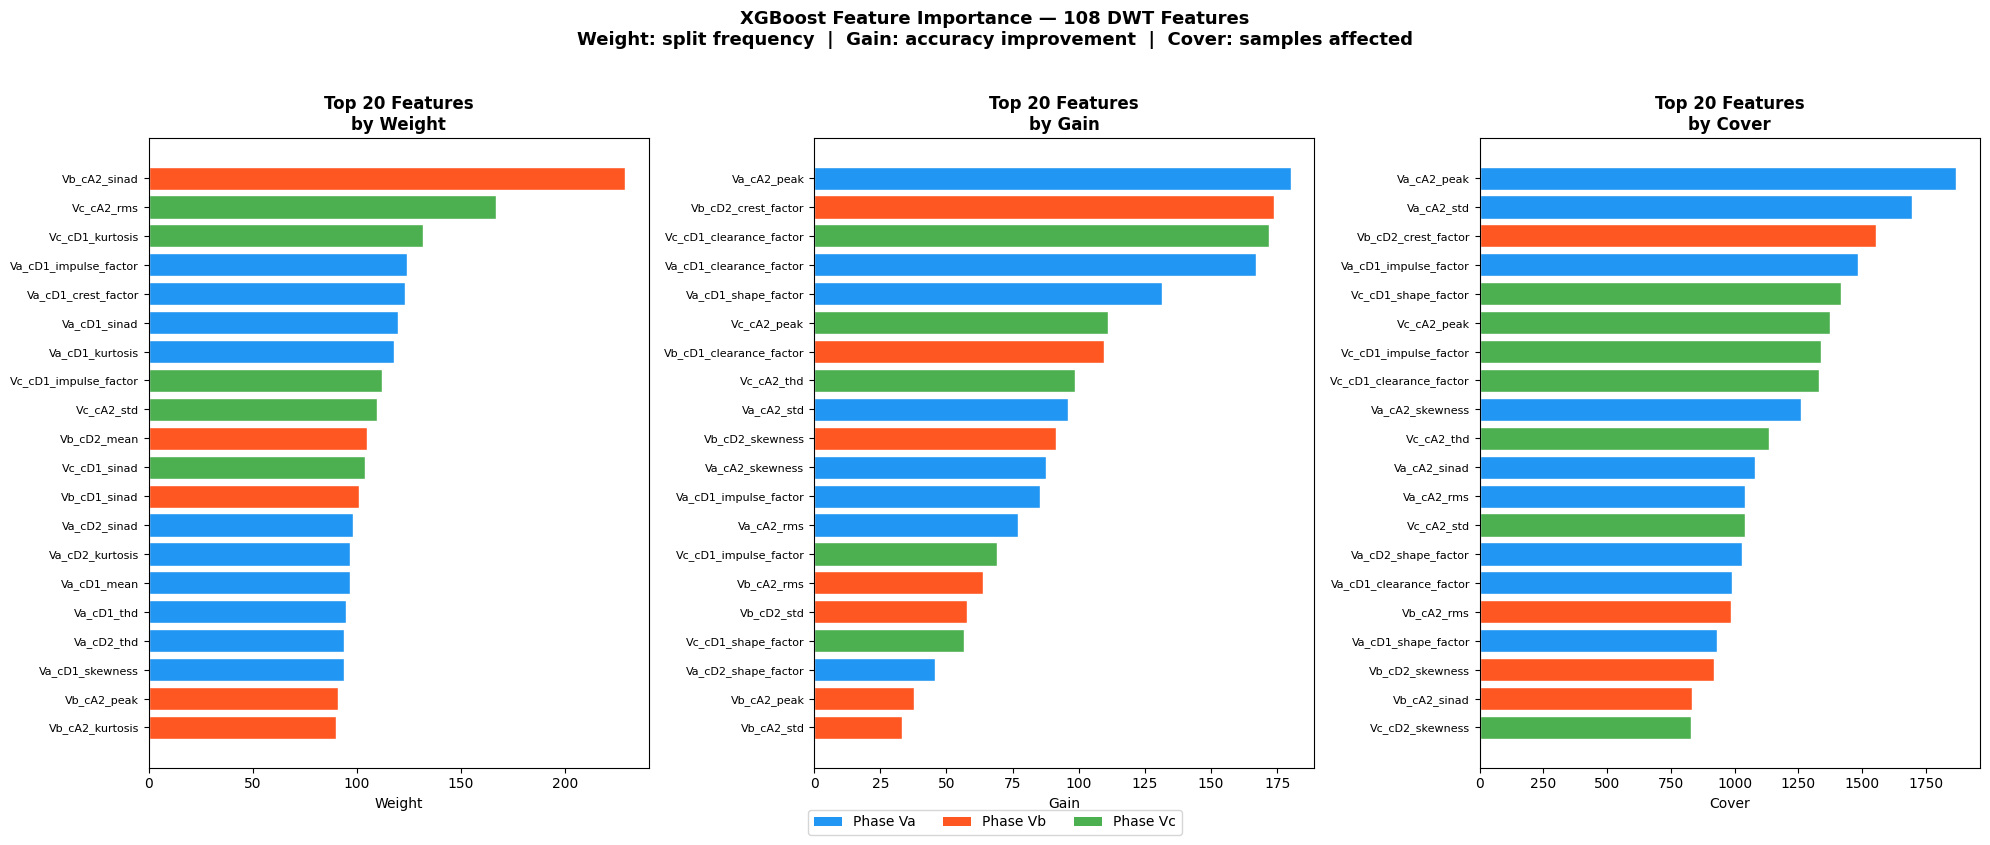


Top 10 Features by Gain (most impactful splits):
Rank   Feature                                   Gain
-----------------------------------------------------
1      Va_cA2_peak                             180.06
2      Vb_cD2_crest_factor                     173.72
3      Vc_cD1_clearance_factor                 171.95
4      Va_cD1_clearance_factor                 166.99
5      Va_cD1_shape_factor                     131.28
6      Vc_cA2_peak                             111.04
7      Vb_cD1_clearance_factor                 109.72
8      Vc_cA2_thd                               98.45
9      Va_cA2_std                               96.00
10     Vb_cD2_skewness                          91.44


In [ ]:
# ================================================================
#  XGBOOST - FEATURE IMPORTANCE
#  Top 20 most important features
# ================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Get feature importances ---
importance_types = ['weight', 'gain', 'cover']
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, imp_type in zip(axes, importance_types):
    # Get importances as dictionary
    scores = xgb_model.get_booster().get_score(importance_type=imp_type)

    # Map f0, f1... back to actual feature names
    named_scores = {FEATURE_NAMES[int(k[1:])]: v for k, v in scores.items()}

    # Sort and take top 20
    sorted_scores = sorted(named_scores.items(), key=lambda x: x[1], reverse=True)[:20]
    features, values = zip(*sorted_scores)

    # Colour by phase
    colors = []
    for f in features:
        if f.startswith('Va'):   colors.append('#2196F3')  # blue
        elif f.startswith('Vb'): colors.append('#FF5722')  # orange
        else:                    colors.append('#4CAF50')  # green

    bars = ax.barh(range(len(features)), values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Features\nby {imp_type.capitalize()}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(imp_type.capitalize(), fontsize=10)

# Legend for phases
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Phase Va'),
    Patch(facecolor='#FF5722', label='Phase Vb'),
    Patch(facecolor='#4CAF50', label='Phase Vc')
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("XGBoost Feature Importance — 108 DWT Features\n"
             "Weight: split frequency  |  Gain: accuracy improvement  |  Cover: samples affected",
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIG_PATH + 'xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print top 10 by gain (most meaningful metric) ---
scores     = xgb_model.get_booster().get_score(importance_type='gain')
named      = {FEATURE_NAMES[int(k[1:])]: v for k, v in scores.items()}
sorted_top = sorted(named.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 Features by Gain (most impactful splits):")
print(f"{'Rank':<6} {'Feature':<35} {'Gain':>10}")
print("-" * 53)
for rank, (feat, val) in enumerate(sorted_top, 1):
    print(f"{rank:<6} {feat:<35} {val:>10.2f}")


  TEST SET COMPARISON — MLP vs XGBoost
  Metric                                     MLP    XGBoost          Δ
---------------------------------------------------------------------------
  Overall Accuracy                        0.9758     0.9753 ▼  0.0005
---------------------------------------------------------------------------

  Non-islanding
    Precision                             0.9730     0.9874 ▲ 0.0144  XGB ✓
    Recall                                0.9905     0.9748 ▼ 0.0157  MLP ✓
    F1-Score                              0.9817     0.9810 ▼ 0.0007  MLP ✓

  Islanding
    Precision                             0.9688     0.9239 ▼ 0.0449  MLP ✓
    Recall                                0.9135     0.9606 ▲ 0.0471  XGB ✓
    F1-Score                              0.9403     0.9419 ▲ 0.0016  XGB ✓

  Line Fault
    Precision                             0.9990     0.9995 ▲ 0.0005  XGB ✓
    Recall                                0.9995     1.0000 ▲ 0.0005  XGB ✓
    F1-Score   

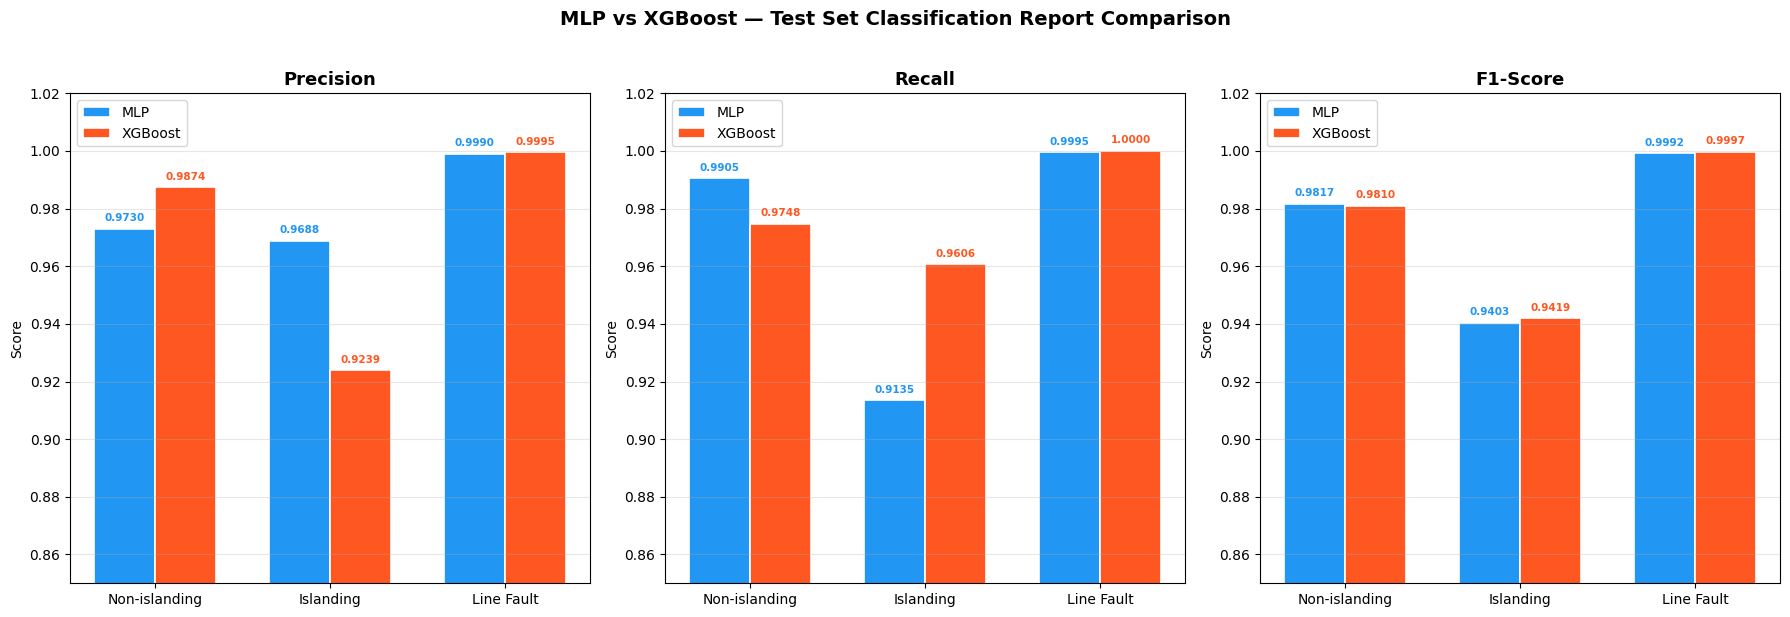

Saved to figures/mlp_vs_xgb_comparison.png


In [ ]:
# ================================================================
#  MLP vs XGBoost — TEST SET CLASSIFICATION REPORT COMPARISON
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

# --- MLP results (hardcoded from documentation) ---
mlp_results = {
    'accuracy': 0.9758,
    'precision': [0.9730, 0.9688, 0.9990],
    'recall':    [0.9905, 0.9135, 0.9995],
    'f1':        [0.9817, 0.9403, 0.9992],
}

# --- XGBoost results (computed) ---
p, r, f, _ = precision_recall_fscore_support(y_test, y_test_pred, labels=[0, 1, 2])
xgb_results = {
    'accuracy':  accuracy_score(y_test, y_test_pred),
    'precision': p.tolist(),
    'recall':    r.tolist(),
    'f1':        f.tolist(),
}

# ================================================================
#  TABLE PRINT
# ================================================================
metrics = ['Precision', 'Recall', 'F1-Score']

print("\n" + "=" * 75)
print(f"  TEST SET COMPARISON — MLP vs XGBoost")
print("=" * 75)
print(f"  {'Metric':<35} {'MLP':>10} {'XGBoost':>10} {'Δ':>10}")
print("-" * 75)

# Overall accuracy
delta = xgb_results['accuracy'] - mlp_results['accuracy']
arrow = "▲" if delta > 0 else "▼"
print(f"  {'Overall Accuracy':<35} {mlp_results['accuracy']:>10.4f} "
      f"{xgb_results['accuracy']:>10.4f} {arrow}{abs(delta):>8.4f}")
print("-" * 75)

# Per class metrics
for i, cls in enumerate(CLASS_NAMES):
    print(f"\n  {cls}")
    for metric, mlp_vals, xgb_vals in zip(
        metrics,
        [mlp_results['precision'], mlp_results['recall'], mlp_results['f1']],
        [xgb_results['precision'], xgb_results['recall'], xgb_results['f1']]
    ):
        mlp_val = mlp_vals[i]
        xgb_val = xgb_vals[i]
        delta   = xgb_val - mlp_val
        arrow   = "▲" if delta > 0 else "▼"
        winner  = "XGB ✓" if delta > 0 else "MLP ✓"
        print(f"    {metric:<33} {mlp_val:>10.4f} {xgb_val:>10.4f} "
              f"{arrow}{abs(delta):>7.4f}  {winner}")

print("\n" + "-" * 75)

# Macro averages
mlp_macro_f1 = np.mean(mlp_results['f1'])
xgb_macro_f1 = np.mean(xgb_results['f1'])
delta        = xgb_macro_f1 - mlp_macro_f1
arrow        = "▲" if delta > 0 else "▼"
print(f"  {'Macro Avg F1':<35} {mlp_macro_f1:>10.4f} "
      f"{xgb_macro_f1:>10.4f} {arrow}{abs(delta):>8.4f}")
print("=" * 75)

# ================================================================
#  BAR CHART COMPARISON
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x      = np.arange(len(CLASS_NAMES))
width  = 0.35
colors = {'MLP': '#2196F3', 'XGBoost': '#FF5722'}

for ax, metric, mlp_vals, xgb_vals in zip(
    axes,
    metrics,
    [mlp_results['precision'], mlp_results['recall'], mlp_results['f1']],
    [xgb_results['precision'], xgb_results['recall'], xgb_results['f1']]
):
    bars1 = ax.bar(x - width/2, mlp_vals, width, label='MLP',
                   color=colors['MLP'], edgecolor='white', linewidth=1.2)
    bars2 = ax.bar(x + width/2, xgb_vals, width, label='XGBoost',
                   color=colors['XGBoost'], edgecolor='white', linewidth=1.2)

    # Value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.4f}', ha='center', va='bottom',
                fontsize=7.5, color=colors['MLP'], fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.4f}', ha='center', va='bottom',
                fontsize=7.5, color=colors['XGBoost'], fontweight='bold')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_ylim(0.85, 1.02)
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("MLP vs XGBoost — Test Set Classification Report Comparison",
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIG_PATH + 'mlp_vs_xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/mlp_vs_xgb_comparison.png")

Proposed Model: Fuzzy Logic + XGBoost

The purpose of this is that XGBoost is not able to correctly classify approximately 4% of islanding scenarios and so to make the algorithm better, Fuzzy logic will be augmented with XGBoost to correctly classify the 4% of islanding scenarios

In [ ]:
# ================================================================
#  STEP 2 — XGBoost Probability Extraction + Ambiguity Analysis
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

# ================================================================
#  CELL 1: Extract probabilities for all three splits
# ================================================================
# Get class probabilities
train_probs = xgb_model.predict_proba(X_train)
val_probs   = xgb_model.predict_proba(X_val)
test_probs  = xgb_model.predict_proba(X_test)

# Get hard predictions
train_preds = np.argmax(train_probs, axis=1)
val_preds   = np.argmax(val_probs,   axis=1)
test_preds  = np.argmax(test_probs,  axis=1)

# Confidence = max probability across the 3 classes
train_conf  = np.max(train_probs, axis=1)
val_conf    = np.max(val_probs,   axis=1)
test_conf   = np.max(test_probs,  axis=1)

print("Probability extraction complete.")
print(f"Test set shape: {test_probs.shape}")
print(f"\nSample probabilities (first 5 test cycles):")
print(f"{'Cycle':<8} {'Non-isl':>10} {'Islanding':>10} {'LineFault':>10} {'Confidence':>12} {'Prediction':>14} {'True Label':>12}")
for i in range(5):
    print(f"{i:<8} {test_probs[i,0]:>10.4f} {test_probs[i,1]:>10.4f} "
          f"{test_probs[i,2]:>10.4f} {test_conf[i]:>12.4f} "
          f"{CLASS_NAMES[test_preds[i]]:>14} {CLASS_NAMES[y_test[i]]:>12}")

Probability extraction complete.
Test set shape: (27495, 3)

Sample probabilities (first 5 test cycles):
Cycle       Non-isl  Islanding  LineFault   Confidence     Prediction   True Label
0            0.9996     0.0000     0.0004       0.9996  Non-islanding Non-islanding
1            0.9895     0.0105     0.0000       0.9895  Non-islanding Non-islanding
2            0.9885     0.0115     0.0000       0.9885  Non-islanding Non-islanding
3            0.6758     0.3242     0.0001       0.6758  Non-islanding Non-islanding
4            0.9898     0.0102     0.0000       0.9898  Non-islanding Non-islanding


In [ ]:
# ================================================================
#  STEP 2 (VALIDATION) — XGBoost Probability Extraction
#  + Ambiguity Analysis on Validation Set
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]
AMBIGUITY_THRESHOLD = 0.85

# ================================================================
#  CELL 1: Extract probabilities — validation set
# ================================================================
val_probs  = xgb_model.predict_proba(X_val)
val_preds  = np.argmax(val_probs, axis=1)
val_conf   = np.max(val_probs, axis=1)

print("Probability extraction complete — VALIDATION SET")
print(f"Validation set shape: {val_probs.shape}")
print(f"\nSample probabilities (first 5 validation cycles):")
print(f"{'Cycle':<8} {'Non-isl':>10} {'Islanding':>10} {'LineFault':>10} "
      f"{'Confidence':>12} {'Prediction':>16} {'True Label':>16}")
for i in range(5):
    print(f"{i:<8} {val_probs[i,0]:>10.4f} {val_probs[i,1]:>10.4f} "
          f"{val_probs[i,2]:>10.4f} {val_conf[i]:>12.4f} "
          f"{CLASS_NAMES[val_preds[i]]:>16} {CLASS_NAMES[y_val[i]]:>16}")

Probability extraction complete — VALIDATION SET
Validation set shape: (27495, 3)

Sample probabilities (first 5 validation cycles):
Cycle       Non-isl  Islanding  LineFault   Confidence       Prediction       True Label
0            1.0000     0.0000     0.0000       1.0000    Non-islanding    Non-islanding
1            0.9997     0.0003     0.0000       0.9997    Non-islanding    Non-islanding
2            1.0000     0.0000     0.0000       1.0000    Non-islanding    Non-islanding
3            0.9999     0.0001     0.0000       0.9999    Non-islanding    Non-islanding
4            1.0000     0.0000     0.0000       1.0000    Non-islanding    Non-islanding


In [ ]:
# ================================================================
#  CELL 2: Confidence distribution analysis
# ================================================================
AMBIGUITY_THRESHOLD=0.85
confident_mask = val_conf >= AMBIGUITY_THRESHOLD
ambiguous_mask = val_conf <  AMBIGUITY_THRESHOLD

n_confident    = confident_mask.sum()
n_ambiguous    = ambiguous_mask.sum()

print(f"\n{'='*55}")
print(f"  Confidence Analysis — Validation Set")
print(f"  Threshold = {AMBIGUITY_THRESHOLD}")
print(f"{'='*55}")
print(f"Total validation samples:       {len(val_conf):>8,}")
print(f"Confident (>= {AMBIGUITY_THRESHOLD}):          {n_confident:>8,}  "
      f"({n_confident/len(val_conf)*100:.1f}%)")
print(f"Ambiguous (<  {AMBIGUITY_THRESHOLD}):          {n_ambiguous:>8,}  "
      f"({n_ambiguous/len(val_conf)*100:.1f}%)")

print(f"\nAmbiguous samples by true class:")
for i, name in enumerate(CLASS_NAMES):
    n   = ((ambiguous_mask) & (y_val == i)).sum()
    pct = n / n_ambiguous * 100 if n_ambiguous > 0 else 0
    print(f"  {name:<22} {n:>6,}  ({pct:.1f}% of ambiguous)")

print(f"\nAmbiguous samples by predicted class:")
for i, name in enumerate(CLASS_NAMES):
    n = ((ambiguous_mask) & (val_preds == i)).sum()
    print(f"  {name:<22} {n:>6,}")



  Confidence Analysis — Validation Set
  Threshold = 0.85
Total validation samples:         27,495
Confident (>= 0.85):            25,663  (93.3%)
Ambiguous (<  0.85):             1,832  (6.7%)

Ambiguous samples by true class:
  Non-islanding           1,468  (80.1% of ambiguous)
  Islanding                 363  (19.8% of ambiguous)
  Line Fault                  1  (0.1% of ambiguous)

Ambiguous samples by predicted class:
  Non-islanding           1,318
  Islanding                 510
  Line Fault                  4


In [ ]:
# ================================================================
#  CELL 3: Missed islanding detections — NDZ analysis
# ================================================================
isl_mask     = y_val == 1
missed_mask  = (isl_mask) & (val_preds != 1)
correct_mask = (isl_mask) & (val_preds == 1)

n_isl_total  = isl_mask.sum()
n_missed     = missed_mask.sum()
n_correct    = correct_mask.sum()

print(f"\n{'='*55}")
print(f"  Islanding Detection Breakdown — Validation Set")
print(f"{'='*55}")
print(f"Total true islanding cycles:    {n_isl_total:>6,}")
print(f"Correctly detected:             {n_correct:>6,}  "
      f"({n_correct/n_isl_total*100:.2f}%)")
print(f"Missed (NDZ):                   {n_missed:>6,}  "
      f"({n_missed/n_isl_total*100:.2f}%)")

print(f"\nMissed islanding classified as:")
for i, name in enumerate(CLASS_NAMES):
    if i == 1:
        continue
    n = ((missed_mask) & (val_preds == i)).sum()
    print(f"  → {name:<22} {n:>5,}")

print(f"\nConfidence stats — correctly detected islanding:")
print(f"  Mean: {val_conf[correct_mask].mean():.4f}")
print(f"  Min:  {val_conf[correct_mask].min():.4f}")
print(f"  Max:  {val_conf[correct_mask].max():.4f}")

print(f"\nConfidence stats — missed islanding (NDZ cycles):")
print(f"  Mean: {val_conf[missed_mask].mean():.4f}")
print(f"  Min:  {val_conf[missed_mask].min():.4f}")
print(f"  Max:  {val_conf[missed_mask].max():.4f}")

missed_and_ambiguous = (missed_mask) & (ambiguous_mask)
missed_and_confident = (missed_mask) & (confident_mask)

print(f"\nOf the {n_missed} missed islanding cycles:")
print(f"  In ambiguous zone (conf < {AMBIGUITY_THRESHOLD}):  "
      f"{missed_and_ambiguous.sum():>5,}  "
      f"({missed_and_ambiguous.sum()/n_missed*100:.1f}%)"
      f"  ← FIS can target these")
print(f"  In confident zone (conf >= {AMBIGUITY_THRESHOLD}): "
      f"{missed_and_confident.sum():>5,}  "
      f"({missed_and_confident.sum()/n_missed*100:.1f}%)"
      f"  ← hard misclassifications")


  Islanding Detection Breakdown — Validation Set
Total true islanding cycles:     5,712
Correctly detected:              5,485  (96.03%)
Missed (NDZ):                      227  (3.97%)

Missed islanding classified as:
  → Non-islanding            225
  → Line Fault                 2

Confidence stats — correctly detected islanding:
  Mean: 0.9856
  Min:  0.5036
  Max:  1.0000

Confidence stats — missed islanding (NDZ cycles):
  Mean: 0.7365
  Min:  0.4854
  Max:  0.9984

Of the 227 missed islanding cycles:
  In ambiguous zone (conf < 0.85):    166  (73.1%)  ← FIS can target these
  In confident zone (conf >= 0.85):    61  (26.9%)  ← hard misclassifications


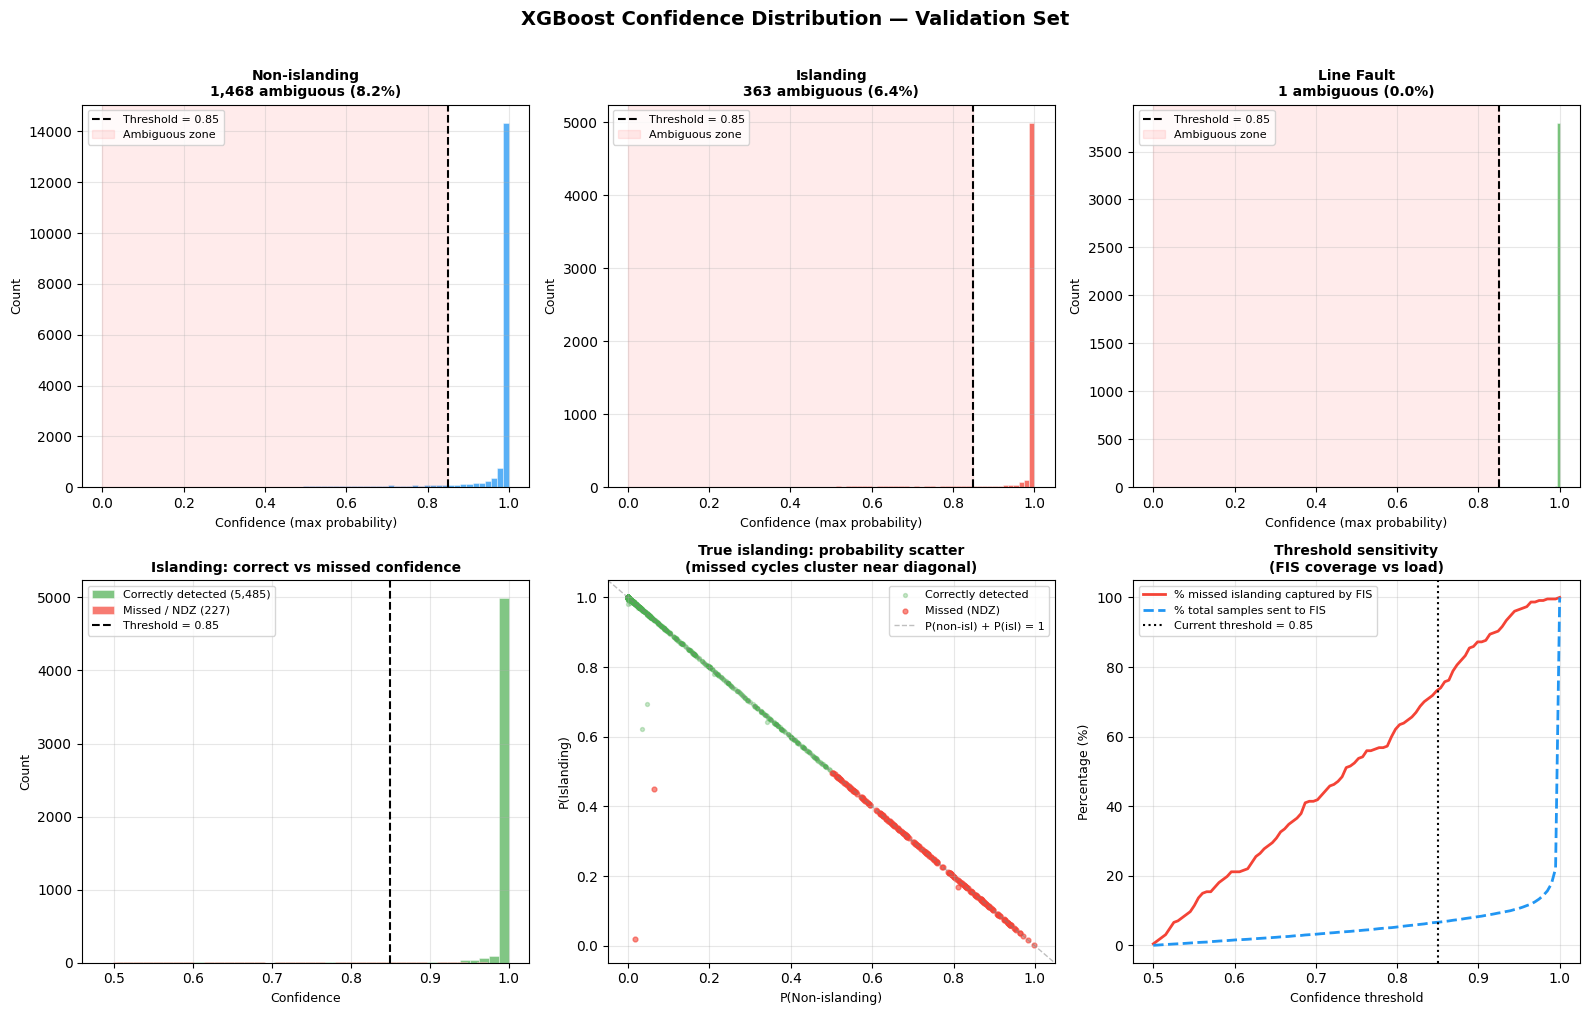

In [ ]:
# ================================================================
#  CELL 4: Confidence distribution plots
# ================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("XGBoost Confidence Distribution — Validation Set",
             fontsize=14, fontweight='bold', y=1.01)

colors = ['#2196F3', '#F44336', '#4CAF50']

# Row 1 — per class histogram
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    ax   = axes[0, i]
    mask = y_val == i
    conf = val_conf[mask]

    ax.hist(conf, bins=40, color=color, alpha=0.75,
            edgecolor='white', linewidth=0.4)
    ax.axvline(AMBIGUITY_THRESHOLD, color='black',
               linestyle='--', linewidth=1.5,
               label=f'Threshold = {AMBIGUITY_THRESHOLD}')
    ax.axvspan(0, AMBIGUITY_THRESHOLD, alpha=0.08,
               color='red', label='Ambiguous zone')

    n_amb = (conf < AMBIGUITY_THRESHOLD).sum()
    ax.set_title(f"{name}\n{n_amb:,} ambiguous "
                 f"({n_amb/len(conf)*100:.1f}%)",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel("Confidence (max probability)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Row 2 — islanding deep dive
# Left: correct vs missed confidence overlay
ax = axes[1, 0]
ax.hist(val_conf[correct_mask], bins=40, color='#4CAF50',
        alpha=0.7, label=f'Correctly detected ({n_correct:,})',
        edgecolor='white', linewidth=0.4)
ax.hist(val_conf[missed_mask], bins=40, color='#F44336',
        alpha=0.7, label=f'Missed / NDZ ({n_missed:,})',
        edgecolor='white', linewidth=0.4)
ax.axvline(AMBIGUITY_THRESHOLD, color='black',
           linestyle='--', linewidth=1.5,
           label=f'Threshold = {AMBIGUITY_THRESHOLD}')
ax.set_title("Islanding: correct vs missed confidence",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Confidence", fontsize=9)
ax.set_ylabel("Count", fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Middle: probability scatter for true islanding cycles
ax = axes[1, 1]
isl_p_nonisl  = val_probs[isl_mask, 0]
isl_p_isl     = val_probs[isl_mask, 1]
isl_correct_m = correct_mask[isl_mask]
isl_missed_m  = missed_mask[isl_mask]

ax.scatter(isl_p_nonisl[isl_correct_m], isl_p_isl[isl_correct_m],
           c='#4CAF50', alpha=0.3, s=8,
           label='Correctly detected')
ax.scatter(isl_p_nonisl[isl_missed_m],  isl_p_isl[isl_missed_m],
           c='#F44336', alpha=0.6, s=12,
           label='Missed (NDZ)')
ax.axline((0, 1), slope=-1, color='gray', linestyle='--',
          linewidth=1, alpha=0.5,
          label='P(non-isl) + P(isl) = 1')
ax.set_xlabel("P(Non-islanding)", fontsize=9)
ax.set_ylabel("P(Islanding)", fontsize=9)
ax.set_title("True islanding: probability scatter\n"
             "(missed cycles cluster near diagonal)",
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: threshold sensitivity curve
ax         = axes[1, 2]
thresholds = np.linspace(0.5, 1.0, 100)
pct_missed_captured = []
pct_total_to_fis    = []

for t in thresholds:
    amb  = val_conf < t
    m_in = ((missed_mask) & amb).sum()
    pct_missed_captured.append(m_in / n_missed * 100
                                if n_missed > 0 else 0)
    pct_total_to_fis.append(amb.sum() / len(val_conf) * 100)

ax.plot(thresholds, pct_missed_captured,
        color='#F44336', linewidth=2,
        label='% missed islanding captured by FIS')
ax.plot(thresholds, pct_total_to_fis,
        color='#2196F3', linewidth=2, linestyle='--',
        label='% total samples sent to FIS')
ax.axvline(AMBIGUITY_THRESHOLD, color='black',
           linestyle=':', linewidth=1.5,
           label=f'Current threshold = {AMBIGUITY_THRESHOLD}')
ax.set_xlabel("Confidence threshold", fontsize=9)
ax.set_ylabel("Percentage (%)", fontsize=9)
ax.set_title("Threshold sensitivity\n"
             "(FIS coverage vs load)",
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_PATH + "val_xgb_confidence_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

# ── Get probabilities on all three splits ───────────────────────
train_probs = xgb_model.predict_proba(X_train)
val_probs   = xgb_model.predict_proba(X_val)
test_probs  = xgb_model.predict_proba(X_test)

isl_mask_train  = y_train == 1
non_mask_train  = y_train == 0
isl_total_train = isl_mask_train.sum()

isl_mask_val    = y_val == 1
non_mask_val    = y_val == 0
isl_total_val   = isl_mask_val.sum()

isl_mask_test   = y_test == 1
non_mask_test   = y_test == 0
isl_total_test  = isl_mask_test.sum()

def print_full_metrics(name, preds, y_true, non_mask):
    """Print precision, recall, F1, accuracy and false alarms."""
    acc       = accuracy_score(y_true, preds) * 100
    prec_mac  = precision_score(y_true, preds, average='macro',
                                zero_division=0) * 100
    rec_mac   = recall_score(y_true, preds, average='macro',
                             zero_division=0) * 100
    f1_mac    = f1_score(y_true, preds, average='macro',
                         zero_division=0) * 100
    isl_prec  = precision_score(y_true, preds, labels=[1],
                                average='micro', zero_division=0) * 100
    isl_rec   = recall_score(y_true, preds, labels=[1],
                             average='micro', zero_division=0) * 100
    isl_f1    = f1_score(y_true, preds, labels=[1],
                         average='micro', zero_division=0) * 100
    fa        = ((preds == 1) & non_mask).sum()
    missed    = ((preds != 1) & (y_true == 1)).sum()

    print(f"\n  ── {name} ──")
    print(f"  {'Metric':<28} {'Value':>10}")
    print(f"  {'-'*40}")
    print(f"  {'Overall Accuracy':<28} {acc:>9.2f}%")
    print(f"  {'Macro Precision':<28} {prec_mac:>9.2f}%")
    print(f"  {'Macro Recall':<28} {rec_mac:>9.2f}%")
    print(f"  {'Macro F1':<28} {f1_mac:>9.2f}%")
    print(f"  {'-'*40}")
    print(f"  {'Islanding Precision':<28} {isl_prec:>9.2f}%")
    print(f"  {'Islanding Recall':<28} {isl_rec:>9.2f}%")
    print(f"  {'Islanding F1':<28} {isl_f1:>9.2f}%")
    print(f"  {'False Alarms':<28} {fa:>10,}")
    print(f"  {'Missed Islanding':<28} {missed:>10,}")

# ── STAGE 1: Sweep on TRAINING SET to find best threshold ───────
print("=" * 62)
print("  STAGE 1 — Threshold sweep on TRAINING SET")
print("=" * 62)
print(f"  {'Thresh':>8} {'Isl_Recall':>12} {'Isl_Prec':>10} "
      f"{'Isl_F1':>10} {'Accuracy':>10} {'False_Alarms':>14} {'Missed':>8}")
print(f"  {'-'*76}")

base_train  = np.argmax(train_probs, axis=1)
base_recall = (base_train[isl_mask_train] == 1).sum() / isl_total_train
base_fa     = ((base_train == 1) & non_mask_train).sum()
base_missed = (base_train[isl_mask_train] != 1).sum()
base_prec   = precision_score(y_train, base_train,
                               labels=[1], average='micro') * 100
base_f1     = f1_score(y_train, base_train,
                        labels=[1], average='micro') * 100
base_acc    = accuracy_score(y_train, base_train) * 100
print(f"  {'argmax':>8} {base_recall*100:>11.2f}% "
      f"{base_prec:>9.2f}% {base_f1:>9.2f}% "
      f"{base_acc:>9.2f}% {base_fa:>14,} "
      f"{base_missed:>8,}  ← current")

best_thresh = None
best_score  = -np.inf

for thresh in np.arange(0.10, 0.50, 0.05):
    preds  = np.where(train_probs[:, 1] >= thresh, 1,
                      np.where(train_probs[:, 0] >= train_probs[:, 2], 0, 2))
    recall = (preds[isl_mask_train] == 1).sum() / isl_total_train
    fa     = ((preds == 1) & non_mask_train).sum()
    missed = (preds[isl_mask_train] != 1).sum()
    prec   = precision_score(y_train, preds,
                              labels=[1], average='micro',
                              zero_division=0) * 100
    f1     = f1_score(y_train, preds,
                       labels=[1], average='micro',
                       zero_division=0) * 100
    acc    = accuracy_score(y_train, preds) * 100

    # Score: reward recall gain, penalise false alarm increase
    score  = (recall - base_recall) * 100 - (fa - base_fa) * 0.01
    if score > best_score:
        best_score  = score
        best_thresh = thresh

    print(f"  {thresh:>8.2f} {recall*100:>11.2f}% "
          f"{prec:>9.2f}% {f1:>9.2f}% "
          f"{acc:>9.2f}% {fa:>14,} {missed:>8,}")

print(f"\n  → Best threshold from training: {best_thresh:.2f}")

# ── STAGE 2: Validation SET ─────────────────────────────────────
print(f"\n{'='*62}")
print(f"  STAGE 2 — VALIDATION SET  (threshold = {best_thresh:.2f})")
print(f"{'='*62}")

base_val   = np.argmax(val_probs, axis=1)
thresh_val = np.where(val_probs[:, 1] >= best_thresh, 1,
                      np.where(val_probs[:, 0] >= val_probs[:, 2], 0, 2))

print_full_metrics("XGBoost argmax",
                   base_val, y_val, non_mask_val)
print_full_metrics(f"Adaptive threshold = {best_thresh:.2f}",
                   thresh_val, y_val, non_mask_val)

print(f"\n  Per-class report — Adaptive threshold (validation):")
print(classification_report(y_val, thresh_val,
                             target_names=CLASS_NAMES, digits=4))



  STAGE 1 — Threshold sweep on TRAINING SET
    Thresh   Isl_Recall   Isl_Prec     Isl_F1   Accuracy   False_Alarms   Missed
  ----------------------------------------------------------------------------
    argmax       99.78%     99.89%     99.84%     99.88%             18       37  ← current
      0.10      100.00%     93.98%     96.90%     97.60%          1,097        0
      0.15      100.00%     96.55%     98.25%     98.66%            612        0
      0.20      100.00%     97.93%     98.95%     99.21%            362        0
      0.25      100.00%     98.81%     99.40%     99.55%            207        0
      0.30       99.99%     99.28%     99.64%     99.73%            124        1
      0.35       99.97%     99.56%     99.76%     99.82%             76        5
      0.40       99.94%     99.70%     99.82%     99.86%             51       11
      0.45       99.89%     99.83%     99.86%     99.90%             29       19

  → Best threshold from training: 0.45

  STAGE 2 — VAL

In [ ]:
import joblib

# Save
joblib.dump(xgb_model, '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/models/xgb_model.pkl')

['/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/models/xgb_model.pkl']

In [ ]:
import numpy as np
import joblib

save_path = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/'

# ── XGBoost argmax predictions ───────────────────────────────────
xgb_test_probs  = xgb_model.predict_proba(X_test)
xgb_test_preds  = np.argmax(xgb_test_probs, axis=1)

# ── XGBoost adaptive threshold predictions ───────────────────────
xgb_thresh_preds = np.where(xgb_test_probs[:, 1] >= 0.45, 1,
                             np.where(xgb_test_probs[:, 0] >=
                                      xgb_test_probs[:, 2], 0, 2))


# ── Save all ─────────────────────────────────────────────────────
np.save(save_path + 'xgb_test_preds.npy',        xgb_test_preds)
np.save(save_path + 'xgb_thresh_test_preds.npy', xgb_thresh_preds)